分析洪水峰值预测精度...
分析洪水检测性能...

洪水预测性能分析摘要

洪水阈值（P90）: 1450.00 m³/s

【峰值预测精度】
--------------------------------------------------------------------------------
模型              峰值数          平均绝对误差          平均相对误差         RMSE
--------------------------------------------------------------------------------
LR               62       600.88 m³/s       -16.85%       797.99
ANN              62       523.56 m³/s       -14.99%       707.60
RF               62      1133.23 m³/s       -28.23%      1633.99
XGB              62       726.98 m³/s       -17.46%      1015.25
--------------------------------------------------------------------------------

【洪水检测性能】
--------------------------------------------------------------------------------
模型                准确率        查准率        查全率       F1分数        误报率        漏报率
--------------------------------------------------------------------------------
LR            97.44%    86.39%    88.48%    87.43%     1.56%    11.52%
ANN           97.84%    89.12%    89.39

C:\Users\Administrator\AppData\Local\Temp\ipykernel_32708\2317637550.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(peak_errors_data, labels=models, patch_artist=True,


✓ Flood analysis chart saved to: results/Figure4_flood_analysis.png


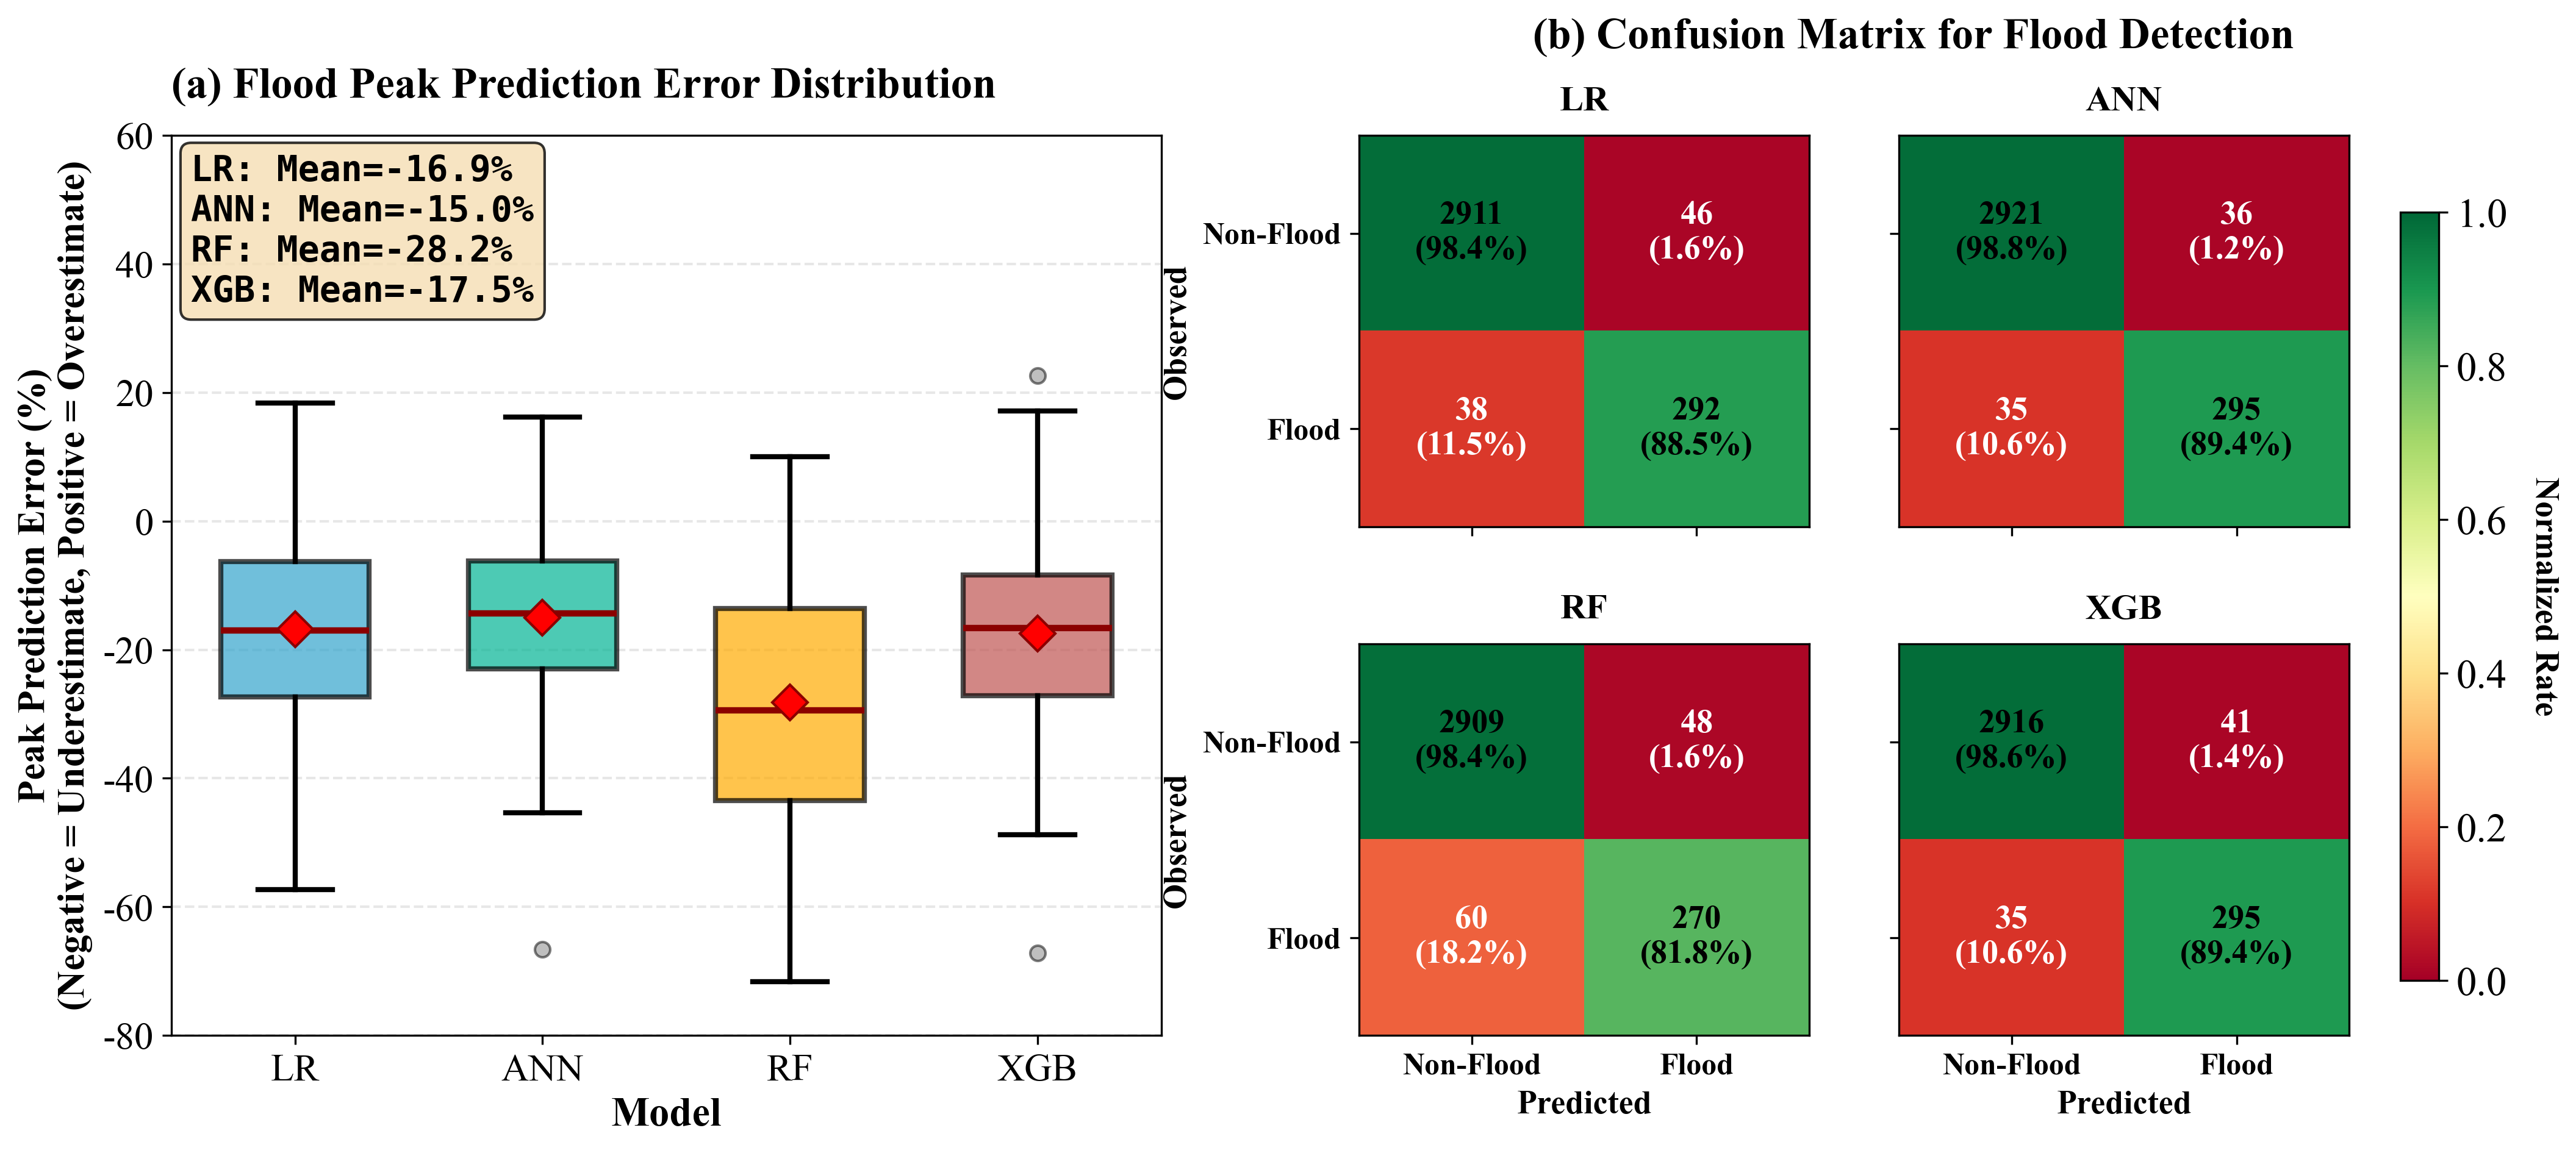


✓ 洪水预测分析完成！


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from sklearn.metrics import confusion_matrix

# 设置字体为英文罗马字体
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 14

def analyze_flood_peak_prediction(results_dir='results', flood_percentile=90):
    """
    分析洪水峰值预测精度
    """
    models = ['LR', 'ANN', 'RF', 'XGB']
    
    peak_analysis = {}
    
    for model in models:
        pred_file = f'predictions/with_typhoon_enhanced_{model}_predictions.csv'
        pred_df = pd.read_csv(pred_file)
        
        obs = pred_df['observed'].values
        pred = pred_df['predicted'].values
        
        # 确定洪水阈值
        flood_threshold = np.percentile(obs, flood_percentile)
        
        # 识别洪水事件
        flood_mask = obs >= flood_threshold
        flood_obs = obs[flood_mask]
        flood_pred = pred[flood_mask]
        
        # 峰值分析
        peak_errors = []
        peak_relative_errors = []
        
        # 找出所有峰值（局部最大值）
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(obs, distance=5, prominence=flood_threshold*0.3)
        
        # 只关注洪水级别的峰值
        flood_peaks = peaks[obs[peaks] >= flood_threshold]
        
        for peak_idx in flood_peaks:
            obs_peak = obs[peak_idx]
            pred_peak = pred[peak_idx]
            
            # 绝对误差
            error = pred_peak - obs_peak
            peak_errors.append(error)
            
            # 相对误差 (%)
            rel_error = (error / obs_peak) * 100
            peak_relative_errors.append(rel_error)
        
        # 统计指标
        peak_analysis[model] = {
            'num_peaks': len(flood_peaks),
            'mean_abs_error': np.mean(np.abs(peak_errors)),
            'mean_relative_error': np.mean(peak_relative_errors),
            'rmse_peaks': np.sqrt(np.mean(np.array(peak_errors)**2)),
            'peak_errors': peak_errors,
            'peak_relative_errors': peak_relative_errors,
            'underestimate_count': np.sum(np.array(peak_errors) < 0),
            'overestimate_count': np.sum(np.array(peak_errors) > 0)
        }
    
    return peak_analysis, flood_threshold

def analyze_flood_detection(results_dir='results', flood_percentile=90):
    """
    分析洪水事件的误报率和漏报率
    """
    models = ['LR', 'ANN', 'RF', 'XGB']
    
    detection_analysis = {}
    confusion_matrices = {}
    
    for model in models:
        pred_file = f'predictions/with_typhoon_enhanced_{model}_predictions.csv'
        pred_df = pd.read_csv(pred_file)
        
        obs = pred_df['observed'].values
        pred = pred_df['predicted'].values
        
        # 确定洪水阈值
        flood_threshold = np.percentile(obs, flood_percentile)
        
        # 二分类：是否为洪水
        obs_binary = (obs >= flood_threshold).astype(int)
        pred_binary = (pred >= flood_threshold).astype(int)
        
        # 混淆矩阵
        cm = confusion_matrix(obs_binary, pred_binary)
        confusion_matrices[model] = cm
        
        tn, fp, fn, tp = cm.ravel()
        
        # 计算指标
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0  # 查准率
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # 查全率（检测率）
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0  # 误报率
        miss_rate = fn / (fn + tp) if (fn + tp) > 0 else 0  # 漏报率
        
        accuracy = (tp + tn) / (tp + tn + fp + fn)  # 准确率
        
        detection_analysis[model] = {
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
            'false_alarm_rate': false_alarm_rate,
            'miss_rate': miss_rate,
            'accuracy': accuracy
        }
    
    return detection_analysis, confusion_matrices, flood_threshold

def plot_flood_analysis_simple(peak_analysis, detection_analysis, confusion_matrices, flood_threshold,
                               output_file='results/Figure4_flood_analysis.png',
                               figsize=(14, 6), dpi=300):
    """
    绘制洪水预测分析图（1行2列：箱线图 + 混淆矩阵）
    """
    models = list(peak_analysis.keys())
    colors = ['#33a4cc', '#02b494', '#ffab00', '#c05452']
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)

    
    # ==================== (a) 峰值预测误差分布（箱线图）====================
    ax1 = axes[0]
    
    peak_errors_data = [peak_analysis[model]['peak_relative_errors'] for model in models]
    
    bp = ax1.boxplot(peak_errors_data, labels=models, patch_artist=True,
                     widths=0.6, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=10, markeredgecolor='darkred'),
                     medianprops=dict(color='darkred', linewidth=2.5),
                     boxprops=dict(linewidth=2),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='gray', markersize=6, alpha=0.5))
    
    # 设置箱体颜色
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
    
      
    ax1.set_ylabel('Peak Prediction Error (%)\n(Negative = Underestimate, Positive = Overestimate)', 
                  fontsize=15, fontweight='bold')
    ax1.set_title('(a) Flood Peak Prediction Error Distribution', fontsize=17, 
                  fontweight='bold', loc='left', pad=15)
    ax1.set_xlabel('Model', fontsize=16, fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.3, linewidth=1)
    ax1.set_ylim([-80, 60])
    ax1.tick_params(axis='both', labelsize=15)
    
    # 添加统计信息文本框
    stats_text = ""
    for i, model in enumerate(models):
        mean_error = peak_analysis[model]['mean_relative_error']
        num_peaks = peak_analysis[model]['num_peaks']
        stats_text += f"{model}: Mean={mean_error:+.1f}%\n"
    
    ax1.text(0.02, 0.98, stats_text.strip(), transform=ax1.transAxes,
            fontsize=14, verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black'),
            family='monospace', fontweight='bold')
    
    # ==================== (b) 混淆矩阵热力图（4个模型）====================
    ax2 = axes[1]
    
    # 创建4个子图网格在一个大的ax2中
    from matplotlib.gridspec import GridSpecFromSubplotSpec
    gs = GridSpecFromSubplotSpec(2, 2, subplot_spec=ax2.get_subplotspec(), 
                                 hspace=0.3, wspace=0.2)
    ax2.remove()  # 移除原始ax2
    
    for idx, model in enumerate(models):
        ax_sub = fig.add_subplot(gs[idx // 2, idx % 2])
        
        cm = confusion_matrices[model]
        
        # 归一化混淆矩阵（按行归一化，显示百分比）
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # 绘制热力图
        im = ax_sub.imshow(cm_normalized, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        
        # 设置刻度
        ax_sub.set_xticks([0, 1])
        ax_sub.set_yticks([0, 1])
        if idx == 0 or idx == 2:
            
            ax_sub.set_ylabel('Observed', fontsize=13, fontweight='bold')
            ax_sub.set_yticklabels(['Non-Flood', 'Flood'], fontsize=12, fontweight='bold')
        else:
            ax_sub.set_yticklabels(['', ''])

        if idx == 2 or idx ==3:
            ax_sub.set_xlabel('Predicted', fontsize=13, fontweight='bold')            
            ax_sub.set_xticklabels(['Non-Flood', 'Flood'], fontsize=12, fontweight='bold')
        else:
            ax_sub.set_xticklabels(['', ''])
            
        ax_sub.set_title(f'{model}', fontsize=14, fontweight='bold', 
                        color='black', pad=10)
        
        # 添加数值标签（显示原始数量和百分比）
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                percentage = cm_normalized[i, j] * 100
                
                # 根据背景颜色选择文字颜色
                text_color = 'white' if cm_normalized[i, j] < 0.5 else 'black'
                
                text = ax_sub.text(j, i, f'{count}\n({percentage:.1f}%)',
                                 ha="center", va="center", 
                                 color=text_color, fontsize=13, fontweight='bold')
        
    
    # 添加总标题
    fig.text(0.73, 1, '(b) Confusion Matrix for Flood Detection', 
            fontsize=17, fontweight='bold', ha='center')
    
    # 添加颜色条（在右侧）
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Normalized Rate', fontsize=13, fontweight='bold', rotation=270, labelpad=20)
    
    plt.subplots_adjust(left=0.05, right=0.90, top=0.92, bottom=0.1)
    
    # 保存图像
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', pad_inches=0.3)
    print(f"✓ Flood analysis chart saved to: {output_file}")
    
    plt.show()

def print_flood_analysis_summary(peak_analysis, detection_analysis, flood_threshold):
    """
    打印洪水分析摘要
    """
    models = list(peak_analysis.keys())
    
    print("\n" + "="*80)
    print("洪水预测性能分析摘要")
    print("="*80)
    
    print(f"\n洪水阈值（P90）: {flood_threshold:.2f} m³/s")
    
    print("\n【峰值预测精度】")
    print("-"*80)
    print(f"{'模型':<10} {'峰值数':>8} {'平均绝对误差':>15} {'平均相对误差':>15} {'RMSE':>12}")
    print("-"*80)
    for model in models:
        pa = peak_analysis[model]
        print(f"{model:<10} {pa['num_peaks']:>8} {pa['mean_abs_error']:>12.2f} m³/s "
              f"{pa['mean_relative_error']:>12.2f}% {pa['rmse_peaks']:>12.2f}")
    print("-"*80)
    
    print("\n【洪水检测性能】")
    print("-"*80)
    print(f"{'模型':<10} {'准确率':>10} {'查准率':>10} {'查全率':>10} {'F1分数':>10} {'误报率':>10} {'漏报率':>10}")
    print("-"*80)
    for model in models:
        da = detection_analysis[model]
        print(f"{model:<10} {da['accuracy']:>9.2%} {da['precision']:>9.2%} "
              f"{da['recall']:>9.2%} {da['f1_score']:>9.2%} "
              f"{da['false_alarm_rate']:>9.2%} {da['miss_rate']:>9.2%}")
    print("-"*80)
    
    print("\n【混淆矩阵统计】")
    print("-"*80)
    print(f"{'模型':<10} {'TP':>8} {'TN':>8} {'FP':>8} {'FN':>8}")
    print("-"*80)
    for model in models:
        da = detection_analysis[model]
        print(f"{model:<10} {da['TP']:>8} {da['TN']:>8} {da['FP']:>8} {da['FN']:>8}")
    print("-"*80)
    
    # 找出最佳模型
    best_peak = min(models, key=lambda m: abs(peak_analysis[m]['mean_relative_error']))
    best_f1 = max(models, key=lambda m: detection_analysis[m]['f1_score'])
    best_recall = max(models, key=lambda m: detection_analysis[m]['recall'])
    
    print(f"\n🏆 最佳峰值预测: {best_peak} (平均相对误差 = {peak_analysis[best_peak]['mean_relative_error']:.2f}%)")
    print(f"🏆 最佳F1分数: {best_f1} (F1 = {detection_analysis[best_f1]['f1_score']:.4f})")
    print(f"🏆 最佳检测率: {best_recall} (Recall = {detection_analysis[best_recall]['recall']:.4f})")

if __name__ == "__main__":
    # 分析峰值预测
    print("分析洪水峰值预测精度...")
    peak_analysis, flood_threshold = analyze_flood_peak_prediction()
    
    # 分析误报/漏报
    print("分析洪水检测性能...")
    detection_analysis, confusion_matrices, _ = analyze_flood_detection()
    
    # 打印摘要
    print_flood_analysis_summary(peak_analysis, detection_analysis, flood_threshold)
    
    # 绘制简化分析图
    print("\n生成洪水预测分析图表...")
    plot_flood_analysis_simple(peak_analysis, detection_analysis, confusion_matrices, flood_threshold)
    
    print("\n✓ 洪水预测分析完成！")